
# Lab 5: Scrodinger equation with FDM

 **Exercise** : Solve the radial Schrodinger for Hydrogen atom with FDM

 ### Hydrogen radial equation

The H atom has an electron of mass $m$ a $r$ distance to the pronton. The potential energy is given by

$U(r)= -\dfrac{e^2}{4\pi\epsilon_0}\dfrac{1}{r}$

The Schrodinger's equation for this system is

$$
-\dfrac{\hbar^2}{2m}\nabla^2 \psi(\vec{r}) + -\dfrac{e^2}{4\pi\epsilon_0}\dfrac{1}{r}\psi(\vec{r})= E\,\psi(\vec{r})$$

Primeras cinco energías numéricas:
n = 1: E = -13.486113 eV
n = 2: E = -3.393850 eV
n = 3: E = -1.510244 eV
n = 4: E = -0.849881 eV
n = 5: E = -0.544033 eV

Comparación numérica vs. analítica:
n = 1: FDM = -13.486113 eV, Analítica = -13.605693 eV, Error = 0.879%
n = 2: FDM = -3.393850 eV, Analítica = -3.401423 eV, Error = 0.223%
n = 3: FDM = -1.510244 eV, Analítica = -1.511744 eV, Error = 0.099%
n = 4: FDM = -0.849881 eV, Analítica = -0.850356 eV, Error = 0.056%
n = 5: FDM = -0.544033 eV, Analítica = -0.544228 eV, Error = 0.036%


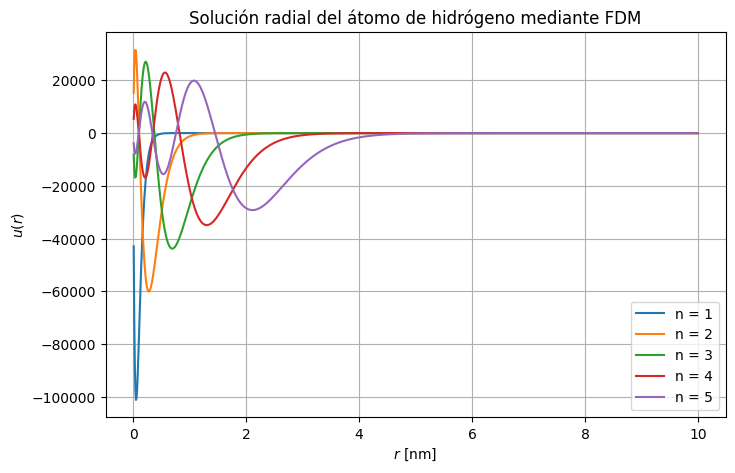

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Constantes físicas

hbar = 1.054571817e-34
m = 9.1093837e-31
e = 1.602176634e-19
epsilon0 = 8.8541878128e-12

# 2. Malla radial

r_max = 10e-9
N = 1000            # número total de puntos

r = np.linspace(0, r_max, N)
dr = r[1] - r[0]

# 3. Puntos interiores
# Las fronteras cumplen:
# u(0) = 0
# u(r_max) = 0


r_in = r[1:-1]
N_in = len(r_in)

# 4. Número cuántico orbital y potencial

l = 0

V = (hbar**2 * l * (l + 1)) / (2 * m * r_in**2) \
    - e**2 / (4 * np.pi * epsilon0 * r_in)

# 5. Construcción del Hamiltoniano mediante FDM

A = -hbar**2 / (2 * m * dr**2)

H = np.zeros((N_in, N_in))

for i in range(N_in):

    # Diagonal principal
    H[i, i] = -2*A + V[i]

    # Diagonal inferior
    if i > 0:
        H[i, i-1] = A

    # Diagonal superior
    if i < N_in - 1:
        H[i, i+1] = A

# 7. Resolver el problema de autovalores

E, u_in = np.linalg.eigh(H)

# 8. Convertir las energías de J a eV

E_eV = E / e

print("Primeras cinco energías numéricas:")
for i in range(5):
    print(f"n = {i+1}: E = {E_eV[i]:.6f} eV")

# 9. Energías analíticas del átomo de hidrógeno

E_analitica = np.array([
    -m * e**4 / (2 * (4*np.pi*epsilon0)**2 * hbar**2 * n**2)
    for n in range(1, 6)
])

E_analitica_eV = E_analitica / e

print("\nComparación numérica vs. analítica:")
for i in range(5):
    error = abs((E_eV[i] - E_analitica_eV[i]) / E_analitica_eV[i]) * 100

    print(
        f"n = {i+1}: "
        f"FDM = {E_eV[i]:.6f} eV, "
        f"Analítica = {E_analitica_eV[i]:.6f} eV, "
        f"Error = {error:.3f}%"
    )

# 10. Preparo y normalizo los primeros estados radiales

plt.figure(figsize=(8, 5))

for i in range(5):

    u = u_in[:, i]

    # Normalización continua:
    # integral |u(r)|^2 dr = 1
    norma = np.sqrt(np.trapezoid(u**2, r_in))
    u = u / norma

    plt.plot(r_in * 1e9, u, label=f"n = {i+1}")

plt.xlabel(r"$r$ [nm]")
plt.ylabel(r"$u(r)$")
plt.title("Solución radial del átomo de hidrógeno mediante FDM")
plt.grid()
plt.legend()
plt.show()